In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports for modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, roc_curve, roc_auc_score)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the processed dataset from previous notebook
df = pd.read_csv('D:/Project/AI-Personalized-Learning-UPSC/backend/data/processed/upsc_prelims_processed.csv')
df.head()

,student_id,age,gender,graduation_percentage,graduation_stream,prep_months,daily_study_hours,mock_tests_attempted,revision_cycles,attempt_number,...,gender_encoded,coaching_encoded,graduation_stream_encoded,target_encoded,has_coaching,regular_quiz_taker,high_mock_tester,consistent_student,ncert_reader,standard_books_user
0,1,27,Female,75,Medical,3,11.7,92,1,3,...,0,1,3,1,1,1,1,1,1,1
1,2,24,Female,71,Engineering,32,6.9,30,1,3,...,0,0,2,0,1,1,0,0,1,1
2,3,33,Male,76,Arts,47,7.8,63,8,6,...,1,0,0,1,1,1,1,0,0,1
3,4,31,Female,91,Science,34,3.0,70,1,4,...,0,1,4,0,1,1,1,0,1,1
4,5,28,Male,69,Engineering,30,4.4,32,5,3,...,1,1,2,0,1,0,0,0,1,1


In [3]:
df.shape

(1000, 84)

In [4]:
# Load the features 

data = pd.read_csv('D:/Project/AI-Personalized-Learning-UPSC/backend/data/processed/features_target.csv')
data.head()

,age,prep_months,daily_study_hours,attempt_number,gs_average_pct,csat_average_pct,overall_score,weak_subjects_count,very_weak_subjects,strong_subjects_count,...,weekly_study_hours,preparation_intensity,has_coaching,regular_quiz_taker,high_mock_tester,ncert_reader,standard_books_user,gender_encoded,graduation_stream_encoded,target
0,-0.107746,-1.734909,1.562805,-0.301288,0.578712,0.375756,0.605105,-0.025633,-0.869336,0.668253,...,1.562805,-1.347800,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,0.686317,1
1,-0.837399,0.542287,-0.424127,-0.301288,-0.556627,-0.565636,-0.649890,0.440418,-0.249710,-0.531483,...,-0.424127,0.195989,0.0,0.588128,-1.059784,0.418435,0.498437,-1.368782,0.066897,0
2,1.351562,1.720147,-0.051577,1.464073,1.647866,0.077056,1.393009,-1.423786,-0.869336,1.867988,...,-0.051577,1.408075,0.0,0.588128,0.943588,-2.389856,0.498437,0.730577,-1.171941,1
3,0.865126,0.699335,-2.038510,0.287165,-0.627904,2.189688,0.206756,0.906469,0.369917,-0.531483,...,-2.038510,-0.791637,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,1.305736,0
4,0.135472,0.385239,-1.458988,-0.301288,0.329243,-0.935183,-0.037622,0.440418,-0.869336,1.867988,...,-1.458988,-0.542237,0.0,-1.700309,-1.059784,0.418435,0.498437,0.730577,0.066897,0


In [5]:
data.shape

(1000, 33)

### Separate Features and Target

In [6]:
# Separate features (X) and target (y)
X = data.drop('target', axis=1)
y = data['target']

In [7]:
X.head()

,age,prep_months,daily_study_hours,attempt_number,gs_average_pct,csat_average_pct,overall_score,weak_subjects_count,very_weak_subjects,strong_subjects_count,...,revision_effectiveness,weekly_study_hours,preparation_intensity,has_coaching,regular_quiz_taker,high_mock_tester,ncert_reader,standard_books_user,gender_encoded,graduation_stream_encoded
0,-0.107746,-1.734909,1.562805,-0.301288,0.578712,0.375756,0.605105,-0.025633,-0.869336,0.668253,...,-1.092875,1.562805,-1.347800,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,0.686317
1,-0.837399,0.542287,-0.424127,-0.301288,-0.556627,-0.565636,-0.649890,0.440418,-0.249710,-0.531483,...,-1.115981,-0.424127,0.195989,0.0,0.588128,-1.059784,0.418435,0.498437,-1.368782,0.066897
2,1.351562,1.720147,-0.051577,1.464073,1.647866,0.077056,1.393009,-1.423786,-0.869336,1.867988,...,2.154705,-0.051577,1.408075,0.0,0.588128,0.943588,-2.389856,0.498437,0.730577,-1.171941
3,0.865126,0.699335,-2.038510,0.287165,-0.627904,2.189688,0.206756,0.906469,0.369917,-0.531483,...,-1.026858,-2.038510,-0.791637,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,1.305736
4,0.135472,0.385239,-1.458988,-0.301288,0.329243,-0.935183,-0.037622,0.440418,-0.869336,1.867988,...,0.031777,-1.458988,-0.542237,0.0,-1.700309,-1.059784,0.418435,0.498437,0.730577,0.066897


In [8]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: target, dtype: int64

### Split Data into Train and Test Sets

In [9]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
X_train.head()

,age,prep_months,daily_study_hours,attempt_number,gs_average_pct,csat_average_pct,overall_score,weak_subjects_count,very_weak_subjects,strong_subjects_count,...,revision_effectiveness,weekly_study_hours,preparation_intensity,has_coaching,regular_quiz_taker,high_mock_tester,ncert_reader,standard_books_user,gender_encoded,graduation_stream_encoded
274,0.621908,-0.871145,-0.134366,-0.889742,-1.518865,-0.636353,-1.471858,1.372520,1.609171,-0.531483,...,-1.425320,-0.134366,-0.755058,0.0,0.588128,-1.059784,-2.389856,0.498437,0.730577,0.686317
179,-0.837399,-0.242953,-1.086438,1.464073,-0.337705,-0.824168,-0.554157,-0.025633,0.369917,-0.531483,...,-0.521825,-1.086438,-0.670262,0.0,-1.700309,-1.059784,0.418435,0.498437,0.730577,1.305736
883,-1.080617,1.013431,-1.210621,0.287165,-0.393708,-1.139691,-0.705499,0.440418,0.369917,-0.531483,...,1.562436,-1.210621,-0.060062,0.0,0.588128,-1.059784,-2.389856,-2.006272,-1.368782,1.305736
357,0.135472,-0.792621,-0.175761,0.875619,0.502344,2.453253,1.232236,-0.491684,-0.869336,-0.531483,...,0.468434,-0.175761,-0.704347,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,-1.171941
194,-0.350963,0.620811,0.238183,0.287165,1.602045,1.704025,1.895745,-1.889837,-0.869336,0.668253,...,1.817074,0.238183,0.692296,0.0,-1.700309,0.943588,0.418435,-2.006272,0.730577,0.066897


In [14]:
X_test.head()

,age,prep_months,daily_study_hours,attempt_number,gs_average_pct,csat_average_pct,overall_score,weak_subjects_count,very_weak_subjects,strong_subjects_count,...,revision_effectiveness,weekly_study_hours,preparation_intensity,has_coaching,regular_quiz_taker,high_mock_tester,ncert_reader,standard_books_user,gender_encoded,graduation_stream_encoded
187,0.865126,0.071143,-1.045044,-0.301288,-2.038168,-0.257750,-1.776938,1.372520,3.468052,-0.531483,...,-1.425320,-1.045044,-0.472405,0.0,0.588128,-1.059784,0.418435,0.498437,0.730577,1.305736
903,-1.323835,-1.499337,-1.252016,-1.478195,-0.582083,1.039217,-0.137606,0.440418,2.228798,-0.531483,...,1.373815,-1.252016,-1.395186,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,-1.171941
728,-0.837399,-0.007381,-0.548310,-0.889742,0.502344,-0.943455,0.103267,-0.957735,-0.249710,-0.531483,...,0.269439,-0.548310,-0.267896,0.0,0.588128,0.943588,0.418435,0.498437,0.730577,-0.552522
393,1.594780,-0.792621,-1.914326,1.464073,-1.951617,-1.477525,-2.110537,1.372520,2.228798,-0.531483,...,0.064786,-1.914326,-1.228088,0.0,0.588128,-1.059784,-2.389856,0.498437,0.730577,-0.552522
654,1.594780,-0.635573,-1.748749,-0.889742,-1.859975,-0.932903,-1.853476,1.838572,2.848425,-0.531483,...,-1.048549,-1.748749,-1.116689,0.0,0.588128,-1.059784,0.418435,0.498437,-1.368782,1.305736


### Define Models to Train

In [15]:
# Define machine learning models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'SVM': SVC(random_state=42, probability=True)
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - K-Nearest Neighbors
  - SVM


### Train and Evaluate All Models

In [18]:
# Store results
results = []
trained_models = {}

print("Training models...")
print("="*60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ Precision: {precision:.4f}")
    print(f"  ✓ Recall: {recall:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")

print("\n" + "="*60)
print("All models trained successfully!")

Training models...

Training Logistic Regression...
  ✓ Accuracy: 0.9400
  ✓ Precision: 0.8873
  ✓ Recall: 0.9403
  ✓ F1-Score: 0.9130

Training Decision Tree...
  ✓ Accuracy: 0.9550
  ✓ Precision: 0.8919
  ✓ Recall: 0.9851
  ✓ F1-Score: 0.9362

Training Random Forest...
  ✓ Accuracy: 0.9500
  ✓ Precision: 0.9014
  ✓ Recall: 0.9552
  ✓ F1-Score: 0.9275

Training Gradient Boosting...
  ✓ Accuracy: 0.9700
  ✓ Precision: 0.9296
  ✓ Recall: 0.9851
  ✓ F1-Score: 0.9565

Training K-Nearest Neighbors...
  ✓ Accuracy: 0.8850
  ✓ Precision: 0.8056
  ✓ Recall: 0.8657
  ✓ F1-Score: 0.8345

Training SVM...
  ✓ Accuracy: 0.9600
  ✓ Precision: 0.9275
  ✓ Recall: 0.9552
  ✓ F1-Score: 0.9412

All models trained successfully!


### Compare Model Performance

In [25]:
# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df.round(4).to_string(index=False))

# Find best model
best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1-Score']
print(f"\n🏆 Best Model: {best_model_name} with F1-Score = {best_f1:.4f}")

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score
  Gradient Boosting     0.970     0.9296  0.9851    0.9565
                SVM     0.960     0.9275  0.9552    0.9412
      Decision Tree     0.955     0.8919  0.9851    0.9362
      Random Forest     0.950     0.9014  0.9552    0.9275
Logistic Regression     0.940     0.8873  0.9403    0.9130
K-Nearest Neighbors     0.885     0.8056  0.8657    0.8345

🏆 Best Model: Gradient Boosting with F1-Score = 0.9565


### Visualize Model Comparison

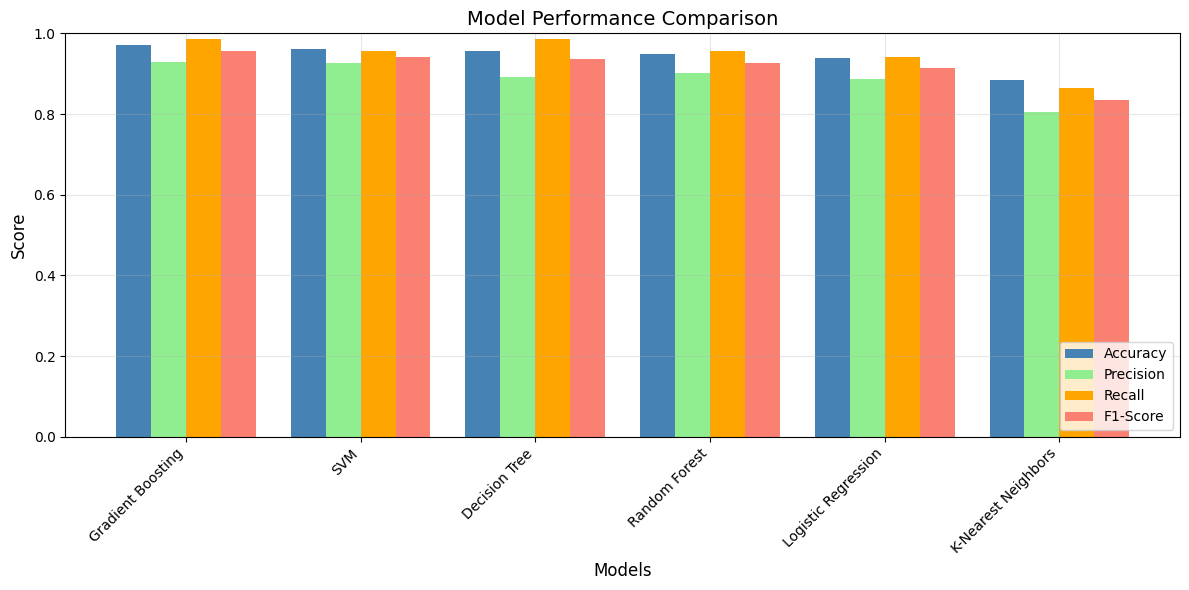

In [26]:
# Plot model comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.2

ax.bar(x - width*1.5, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x - width/2, results_df['Precision'], width, label='Precision', color='lightgreen')
ax.bar(x + width/2, results_df['Recall'], width, label='Recall', color='orange')
ax.bar(x + width*1.5, results_df['F1-Score'], width, label='F1-Score', color='salmon')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Confusion Matrix for Best Model

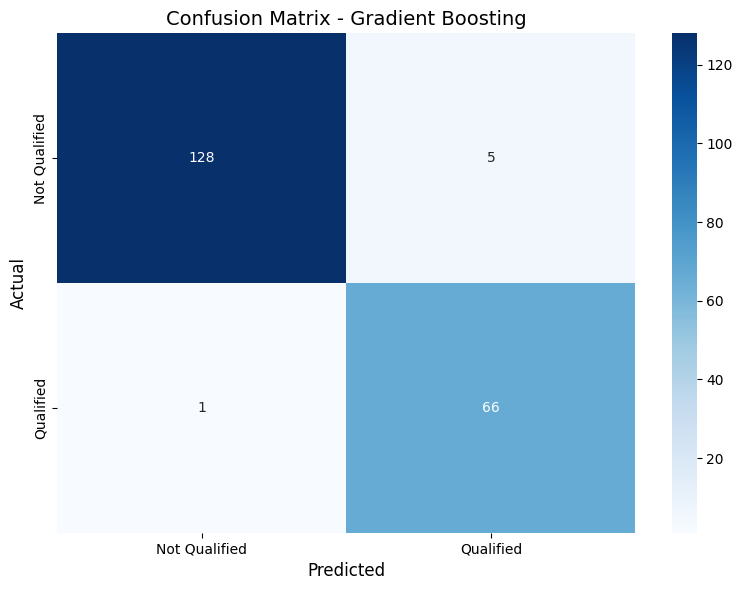


Confusion Matrix Interpretation:
  True Negatives (Correctly predicted Not Qualified): 128
  False Positives (Wrongly predicted Qualified): 5
  False Negatives (Wrongly predicted Not Qualified): 1
  True Positives (Correctly predicted Qualified): 66


In [27]:
# Get best model
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Not Qualified', 'Qualified'],
            yticklabels=['Not Qualified', 'Qualified'])

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14)

plt.tight_layout()
plt.show()

# Print interpretation
print(f"\nConfusion Matrix Interpretation:")
print(f"  True Negatives (Correctly predicted Not Qualified): {cm[0,0]}")
print(f"  False Positives (Wrongly predicted Qualified): {cm[0,1]}")
print(f"  False Negatives (Wrongly predicted Not Qualified): {cm[1,0]}")
print(f"  True Positives (Correctly predicted Qualified): {cm[1,1]}")

### Detailed Classification Report

In [32]:
# Generate classification report
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")

report = classification_report(y_test, y_pred_best, 
                               target_names=['Not Qualified', 'Qualified'])
print(report)

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"\nAdditional Metrics:")
print(f"  Specificity (True Negative Rate): {specificity:.4f}")
print(f"  False Positive Rate: {1-specificity:.4f}")
print(f"  False Negative Rate: {fn/(fn+tp):.4f}")

DETAILED CLASSIFICATION REPORT - Gradient Boosting
               precision    recall  f1-score   support

Not Qualified       0.99      0.96      0.98       133
    Qualified       0.93      0.99      0.96        67

     accuracy                           0.97       200
    macro avg       0.96      0.97      0.97       200
 weighted avg       0.97      0.97      0.97       200


Additional Metrics:
  Specificity (True Negative Rate): 0.9624
  False Positive Rate: 0.0376
  False Negative Rate: 0.0149


### ROC Curve and AUC Score

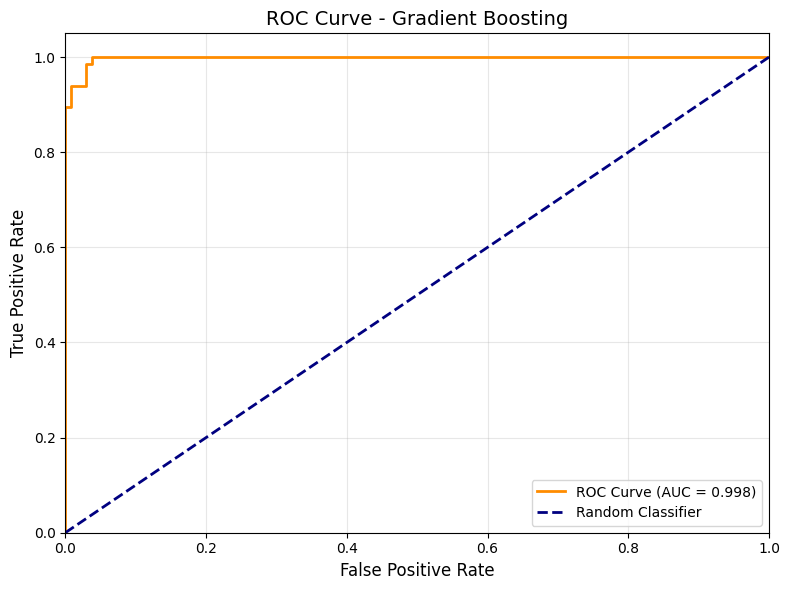

AUC Score: 0.9978
Interpretation: Higher AUC means better model performance


In [35]:
# Plot ROC curve for best model
if hasattr(best_model, "predict_proba"):
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
else:
    y_pred_proba = best_model.decision_function(X_test)
    y_pred_proba = (y_pred_proba - y_pred_proba.min()) / (y_pred_proba.max() - y_pred_proba.min())

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve - {best_model_name}', fontsize=14)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")
print("Interpretation: Higher AUC means better model performance")

### Cross-Validation for Best Model

In [37]:
# Perform cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='f1')

print(f"CROSS-VALIDATION RESULTS - {best_model_name}")

print(f"Fold 1 F1-Score: {cv_scores[0]:.4f}")
print(f"Fold 2 F1-Score: {cv_scores[1]:.4f}")
print(f"Fold 3 F1-Score: {cv_scores[2]:.4f}")
print(f"Fold 4 F1-Score: {cv_scores[3]:.4f}")
print(f"Fold 5 F1-Score: {cv_scores[4]:.4f}")
print(f"\nMean F1-Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

CROSS-VALIDATION RESULTS - Gradient Boosting
Fold 1 F1-Score: 0.9545
Fold 2 F1-Score: 0.9457
Fold 3 F1-Score: 0.9565
Fold 4 F1-Score: 0.9545
Fold 5 F1-Score: 0.9545

Mean F1-Score: 0.9532
Standard Deviation: 0.0038
95% Confidence Interval: [0.9457, 0.9606]


### Feature Importance (Random Forest / Gradient Boosting)

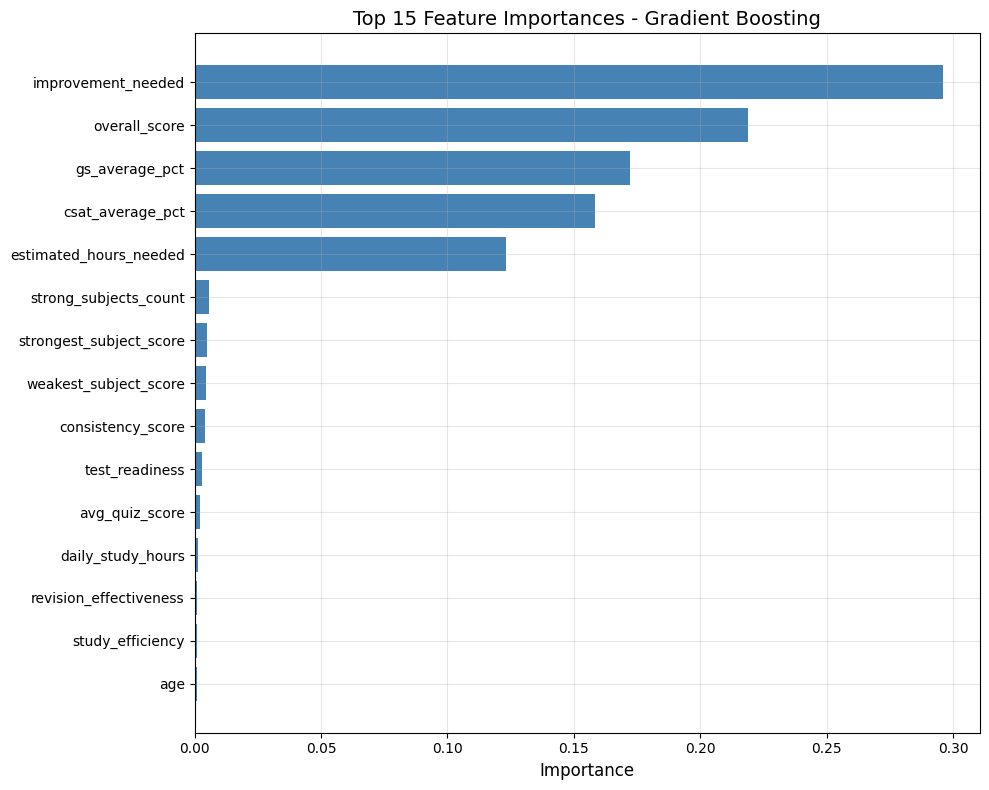


Top 10 Most Important Features:
  1. improvement_needed: 0.2958
  2. overall_score: 0.2188
  3. gs_average_pct: 0.1724
  4. csat_average_pct: 0.1584
  5. estimated_hours_needed: 0.1232
  6. strong_subjects_count: 0.0055
  7. strongest_subject_score: 0.0050
  8. weakest_subject_score: 0.0043
  9. consistency_score: 0.0041
  10. test_readiness: 0.0029


In [40]:
# Check if best model has feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]  # Top 15 features
    
    # Create dataframe for feature importance
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns[indices],
        'Importance': importances[indices]
    })
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(indices)), feature_importance_df['Importance'][::-1], color='steelblue')
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels(feature_importance_df['Feature'][::-1])
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top 15 Feature Importances - {best_model_name}', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    for i, (feature, importance) in enumerate(zip(feature_importance_df['Feature'][:10], 
                                                   feature_importance_df['Importance'][:10]), 1):
        print(f"  {i}. {feature}: {importance:.4f}")
else:
    print(f"{best_model_name} does not provide feature importance")
    print("Try Random Forest or Gradient Boosting for feature importance")

### Hyperparameter Tuning for Best Model

In [41]:
# Hyperparameter tuning for Random Forest (if it's the best or second best)
if best_model_name == 'Random Forest' or best_model_name == 'Gradient Boosting':
    print(f"Performing hyperparameter tuning for {best_model_name}...")
    
    if best_model_name == 'Random Forest':
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        base_model = RandomForestClassifier(random_state=42)
    else:
        param_grid = {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5]
        }
        base_model = GradientBoostingClassifier(random_state=42)
    
    # Perform grid search
    grid_search = GridSearchCV(base_model, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"\nBest parameters found:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")
    
    print(f"\nBest cross-validation F1-Score: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model on test set
    tuned_model = grid_search.best_estimator_
    y_pred_tuned = tuned_model.predict(X_test)
    tuned_f1 = f1_score(y_test, y_pred_tuned)
    
    print(f"Tuned model test F1-Score: {tuned_f1:.4f}")
    print(f"Original model test F1-Score: {best_f1:.4f}")
    
    if tuned_f1 > best_f1:
        print(f"\n✅ Improvement of {(tuned_f1 - best_f1)*100:.2f}%!")
        best_model = tuned_model
        best_model_name = f"{best_model_name} (Tuned)"
    else:
        print("\n⚠️ No improvement from tuning, keeping original model")
else:
    print(f"Hyperparameter tuning skipped for {best_model_name}")
    print("Consider using Random Forest or Gradient Boosting for better performance")

Performing hyperparameter tuning for Gradient Boosting...

Best parameters found:
  learning_rate: 0.05
  max_depth: 3
  min_samples_split: 2
  n_estimators: 100

Best cross-validation F1-Score: 0.9534
Tuned model test F1-Score: 0.9635
Original model test F1-Score: 0.9565

✅ Improvement of 0.70%!


### Save the Best Model

In [43]:
# Save the best model for use in the recommendation engine
import joblib

# Save model
model_save_path = 'D:/Project/AI-Personalized-Learning-UPSC/ml_models/saved_models/'
joblib.dump(best_model, f'{model_save_path}best_upsc_model.pkl')
print(f"✅ Best model saved to '{model_save_path}best_upsc_model.pkl'")

# Save feature names
feature_names = X.columns.tolist()
with open('D:/Project/AI-Personalized-Learning-UPSC/backend/data/models/feature_names.txt', 'w') as f:
    for feature in feature_names:
        f.write(f"{feature}\n")
print(f"✅ Feature names saved as 'feature_names.txt'")

# Save model performance summary
performance_summary = {
    'model_name': best_model_name,
    'accuracy': results_df.iloc[0]['Accuracy'],
    'precision': results_df.iloc[0]['Precision'],
    'recall': results_df.iloc[0]['Recall'],
    'f1_score': results_df.iloc[0]['F1-Score']
}

performance_df = pd.DataFrame([performance_summary])
performance_df.to_csv('D:/Project/AI-Personalized-Learning-UPSC/backend/data/models/model_performance.csv', index=False)
print(f"✅ Model performance saved as 'model_performance.csv'")

✅ Best model saved to 'D:/Project/AI-Personalized-Learning-UPSC/ml_models/saved_models/best_upsc_model.pkl'
✅ Feature names saved as 'feature_names.txt'
✅ Model performance saved as 'model_performance.csv'


### Test Model with Sample Student Data

In [44]:
# Test the model with a few sample students

print("TESTING MODEL WITH SAMPLE STUDENTS")

# Take 5 random students from test set
sample_indices = np.random.choice(X_test.index, min(5, len(X_test)), replace=False)

for idx in sample_indices:
    student_features = X_test.loc[idx:idx]
    actual = y_test.loc[idx]
    predicted = best_model.predict(student_features)[0]
    proba = best_model.predict_proba(student_features)[0] if hasattr(best_model, 'predict_proba') else None
    
    print(f"\nStudent {idx}:")
    print(f"  Actual: {'Qualified' if actual == 1 else 'Not Qualified'}")
    print(f"  Predicted: {'Qualified' if predicted == 1 else 'Not Qualified'}")
    if proba is not None:
        print(f"  Probability of Qualification: {proba[1]*100:.1f}%")
    
    # Show key features
    print(f"  Key features:")
    for col in ['overall_score', 'gs_average_pct', 'csat_average_pct', 'daily_study_hours', 'mock_tests_attempted']:
        if col in student_features.columns:
            value = student_features[col].values[0]
            print(f"    - {col}: {value:.2f}")

TESTING MODEL WITH SAMPLE STUDENTS

Student 232:
  Actual: Not Qualified
  Predicted: Not Qualified
  Probability of Qualification: 1.0%
  Key features:
    - overall_score: 0.04
    - gs_average_pct: -0.07
    - csat_average_pct: 0.27
    - daily_study_hours: 1.73
    - mock_tests_attempted: -0.10

Student 294:
  Actual: Not Qualified
  Predicted: Not Qualified
  Probability of Qualification: 0.6%
  Key features:
    - overall_score: -0.20
    - gs_average_pct: -0.43
    - csat_average_pct: 0.49
    - daily_study_hours: -1.67
    - mock_tests_attempted: 0.89

Student 91:
  Actual: Not Qualified
  Predicted: Not Qualified
  Probability of Qualification: 0.5%
  Key features:
    - overall_score: -1.30
    - gs_average_pct: -1.93
    - csat_average_pct: 0.91
    - daily_study_hours: -1.17
    - mock_tests_attempted: -0.06

Student 850:
  Actual: Not Qualified
  Predicted: Not Qualified
  Probability of Qualification: 0.5%
  Key features:
    - overall_score: -0.61
    - gs_average_pct: -

### Model Prediction Function

In [47]:
# Create a function for making predictions on new students
def predict_qualification(student_data, model, scaler=None, feature_names=None):
    """
    Predict UPSC Prelims qualification for a new student
    
    Parameters:
    - student_data: DataFrame with student features
    - model: trained model
    - scaler: fitted scaler (if used)
    - feature_names: list of feature names expected by model
    
    Returns:
    - prediction: 0 or 1
    - probability: probability of qualification
    """
    # Ensure correct features
    if feature_names is not None:
        missing_features = set(feature_names) - set(student_data.columns)
        if missing_features:
            print(f"Warning: Missing features: {missing_features}")
            for feature in missing_features:
                student_data[feature] = 0  # Add with default value
    
    # Select only needed features
    if feature_names is not None:
        student_data = student_data[feature_names]
    
    # Scale if scaler provided
    if scaler is not None:
        student_data_scaled = scaler.transform(student_data)
    else:
        student_data_scaled = student_data
    
    # Make prediction
    prediction = model.predict(student_data_scaled)[0]
    
    if hasattr(model, 'predict_proba'):
        probability = model.predict_proba(student_data_scaled)[0][1]
    else:
        probability = None
    
    return prediction, probability

print("Prediction function created successfully!")
print("\nExample usage:")
print("  prediction, prob = predict_qualification(new_student_df, best_model, scaler, feature_names)")

Prediction function created successfully!

Example usage:
  prediction, prob = predict_qualification(new_student_df, best_model, scaler, feature_names)


### Visualize Model Performance Summary

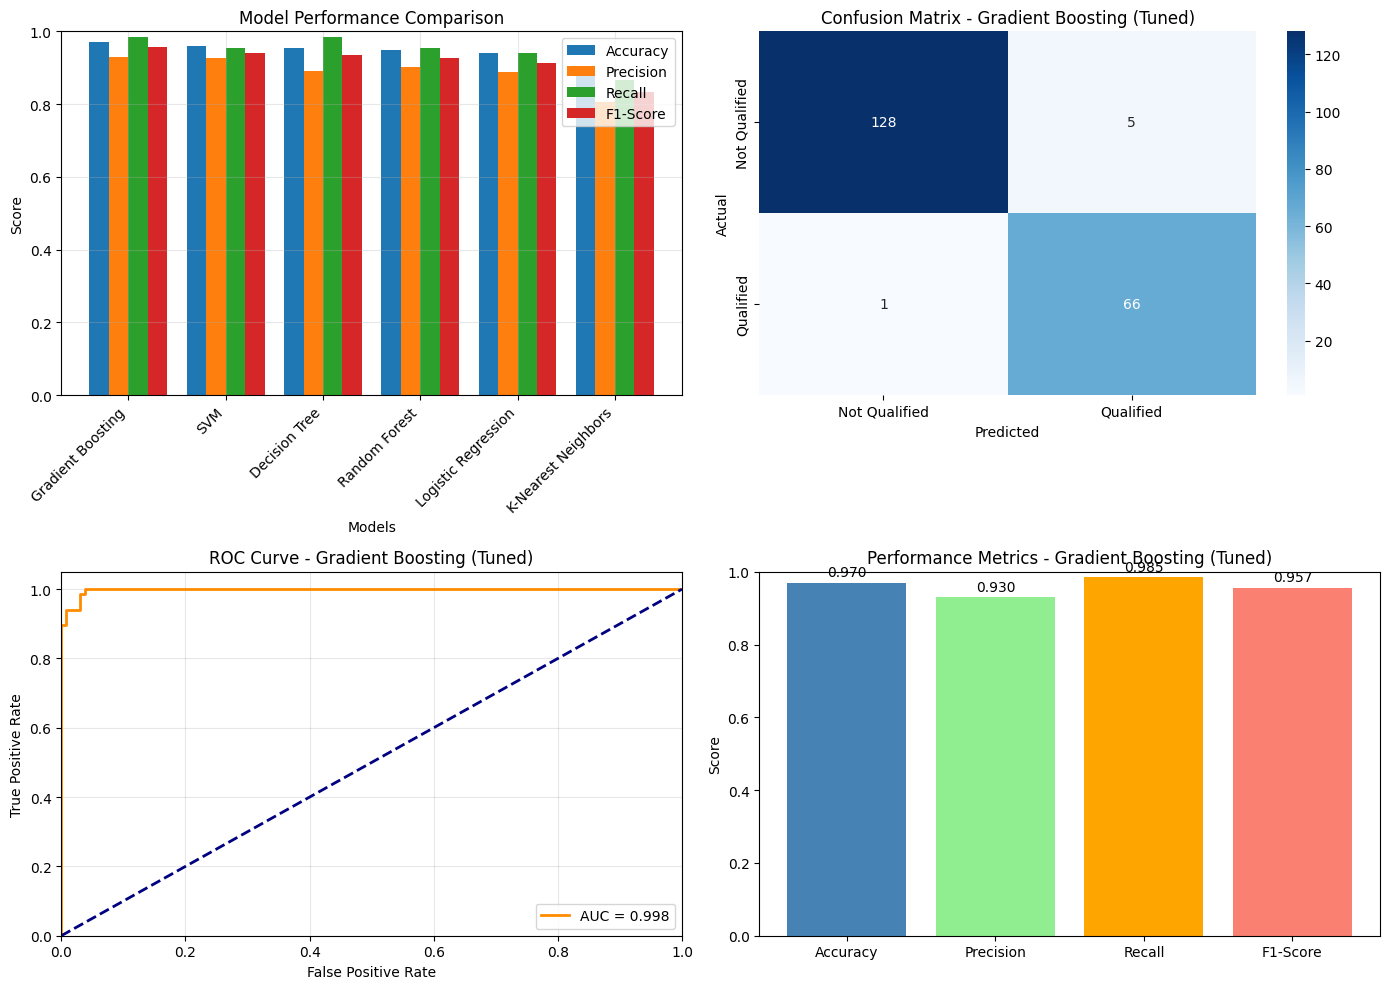


🎉 Model training and evaluation complete!
📊 Ready to integrate with recommendation engine!


In [48]:
# Create a comprehensive performance visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Model comparison bar chart
ax1 = axes[0, 0]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    ax1.bar(x + (i-1.5)*width, results_df[metric], width, label=metric)

ax1.set_xlabel('Models')
ax1.set_ylabel('Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# 2. Best model confusion matrix
ax2 = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Not Qualified', 'Qualified'],
            yticklabels=['Not Qualified', 'Qualified'])
ax2.set_title(f'Confusion Matrix - {best_model_name}')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# 3. ROC Curve
ax3 = axes[1, 0]
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.3f}')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title(f'ROC Curve - {best_model_name}')
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

# 4. Performance metrics bar chart for best model
ax4 = axes[1, 1]
best_metrics = results_df.iloc[0][['Accuracy', 'Precision', 'Recall', 'F1-Score']]
colors = ['steelblue', 'lightgreen', 'orange', 'salmon']
bars = ax4.bar(best_metrics.index, best_metrics.values, color=colors)
ax4.set_ylim(0, 1)
ax4.set_ylabel('Score')
ax4.set_title(f'Performance Metrics - {best_model_name}')
ax4.set_ylim(0, 1)

# Add value labels on bars
for bar, value in zip(bars, best_metrics.values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n🎉 Model training and evaluation complete!")
print("📊 Ready to integrate with recommendation engine!")